In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report
)


In [67]:
df = pd.read_csv("heart-disease.csv")

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [68]:
df.shape

(303, 14)

In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [70]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [71]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [72]:
df = df.drop_duplicates()
df.shape

(302, 14)

In [73]:
df["target"].value_counts()

target
1    164
0    138
Name: count, dtype: int64

# Visualizing

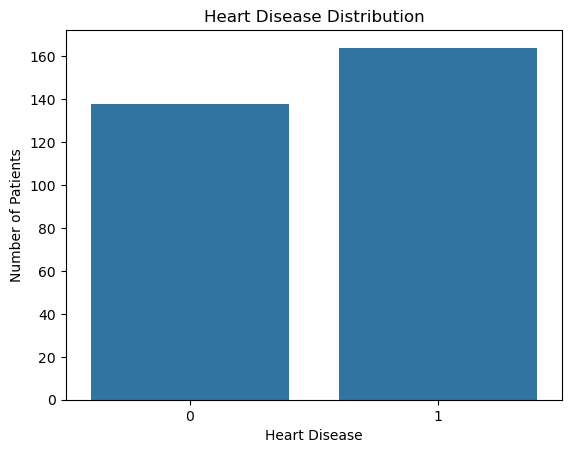

In [74]:
sns.countplot(x="target", data=df)

plt.title("Heart Disease Distribution")
plt.xlabel("Heart Disease")
plt.ylabel("Number of Patients")

plt.show()

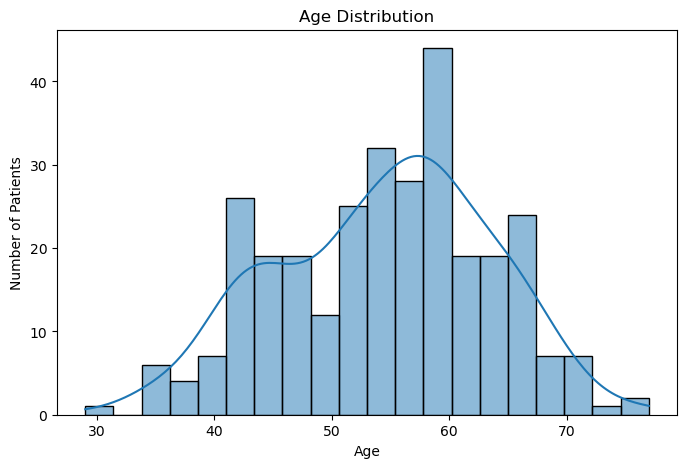

In [75]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df,x="age",bins=20,kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Patients")

plt.show()

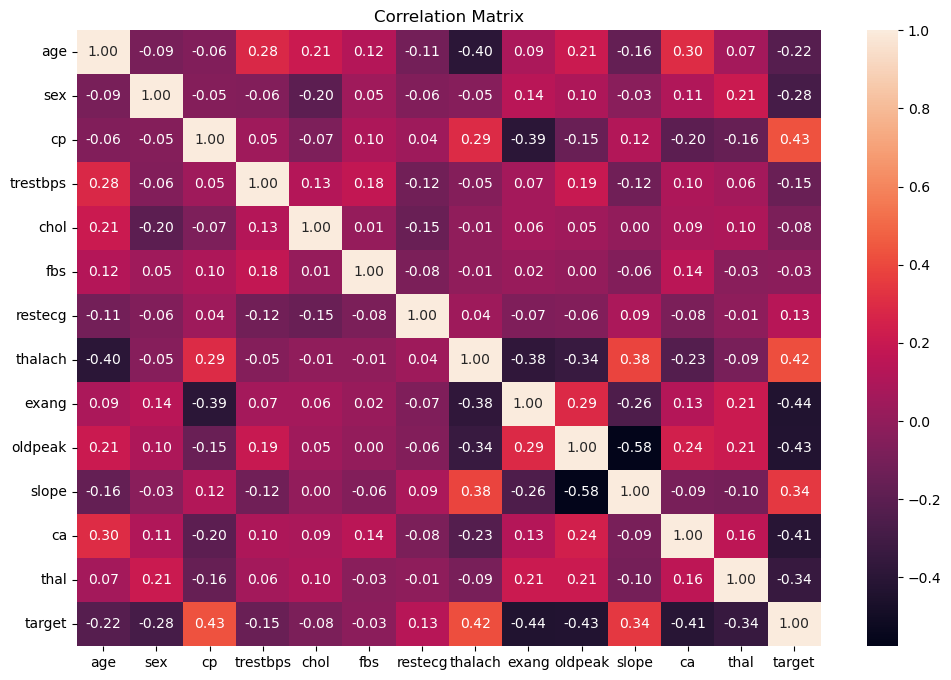

In [76]:
plt.figure(figsize=(12, 8))

sns.heatmap(df.corr(),annot=True,fmt=".2f")

plt.title("Correlation Matrix")

plt.show()

# Splitting data

In [77]:
X= df.drop('target', axis=1)
y = df['target']

In [78]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (302, 13)
y shape: (302,)


In [79]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

# Creating Model

In [80]:
model = ExtraTreesClassifier(
    n_estimators=100,random_state=42
)

# Training the model

In [81]:
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,False
,oob_score,False


In [82]:
y_pred = model.predict(X_test)

In [83]:
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.7868852459016393

In [84]:
classification_report(y_test, y_pred)

'              precision    recall  f1-score   support\n\n           0       0.80      0.71      0.75        28\n           1       0.78      0.85      0.81        33\n\n    accuracy                           0.79        61\n   macro avg       0.79      0.78      0.78        61\nweighted avg       0.79      0.79      0.79        61\n'

In [85]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
2,cp,0.138096
12,thal,0.115141
8,exang,0.107035
11,ca,0.098621
7,thalach,0.084314
9,oldpeak,0.084143
10,slope,0.079427
0,age,0.062901
4,chol,0.061953
3,trestbps,0.060912


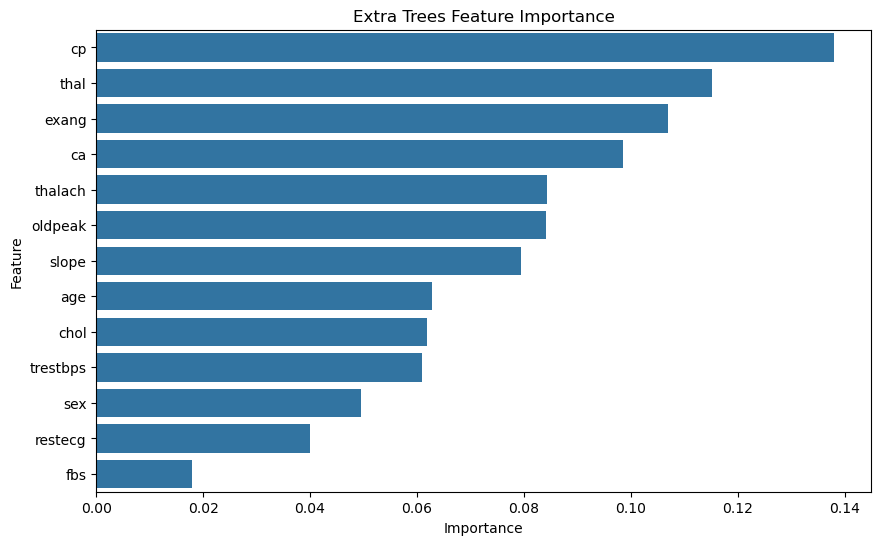

In [86]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Extra Trees Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

# finetuning the model

In [87]:
model_tuned = ExtraTreesClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    random_state=42
)

In [88]:
model_tuned.fit(X_train, y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,False
,oob_score,False


In [89]:
y_pred_tuned = model_tuned.predict(X_test)

In [90]:
tuned_accuracy = accuracy_score(
    y_test,
    y_pred_tuned
)

tuned_accuracy

0.7868852459016393

In [91]:
classification_report(y_test,y_pred_tuned)

'              precision    recall  f1-score   support\n\n           0       0.86      0.64      0.73        28\n           1       0.75      0.91      0.82        33\n\n    accuracy                           0.79        61\n   macro avg       0.80      0.78      0.78        61\nweighted avg       0.80      0.79      0.78        61\n'

In [92]:
basic_accuracy = accuracy_score(
    y_test,
    y_pred
)

tuned_accuracy = accuracy_score(
    y_test,
    y_pred_tuned
)

comparison = pd.DataFrame({
    "Model": [
        "Basic Extra Trees",
        "Tuned Extra Trees"
    ],
    "Accuracy": [
        basic_accuracy,
        tuned_accuracy
    ]
})

comparison

,Model,Accuracy
0,Basic Extra Trees,0.786885
1,Tuned Extra Trees,0.786885


In [93]:
features = ['cp', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
new_X= df[features]
new_y = df['target']

In [94]:
print("X shape:", new_X.shape)
print("y shape:", new_y.shape)

X shape: (302, 7)
y shape: (302,)


In [95]:
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(new_X,new_y,test_size=0.2,random_state=42,stratify=y)

In [96]:
second_model_tuned = ExtraTreesClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    random_state=42
)
model_tuned.fit(X_train_new, y_train_new)
y_pred_tuned_second = model_tuned.predict(X_test_new)

In [97]:
second_tuned_accuracy = accuracy_score(
    y_test_new,
    y_pred_tuned_second
)

second_tuned_accuracy

0.8032786885245902

In [99]:
basic_accuracy = accuracy_score(
    y_test,
    y_pred
)

tuned_accuracy = accuracy_score(
    y_test,
    y_pred_tuned
)

second_tuned_accuracy = accuracy_score(
    y_test_new,
    y_pred_tuned_second
)


comparison = pd.DataFrame({
    "Model": [
        "Basic Extra Trees",
        "Tuned Extra Trees",
        "Second tuned with splitting Features"
    ],
    "Accuracy": [
        basic_accuracy,
        tuned_accuracy,
        second_tuned_accuracy
    ]
})

comparison

,Model,Accuracy
0,Basic Extra Trees,0.786885
1,Tuned Extra Trees,0.786885
2,Second tuned with splitting Features,0.803279
